**Silvia Martín Galán**

# Venn Diagram

### Origen

El diagrama de Venn fue desarrollado en 1880 por el matemático británico
John Venn.

Su objetivo era representar relaciones entre conjuntos en lógica y teoría de conjuntos, mostrando visualmente intersecciones, uniones y diferencias entre grupos.

### Ventajas
- Permite visualizar fácilmente intersecciones entre conjuntos.
- Es intuitivo y fácil de interpretar.
- Facilita identificar elementos exclusivos y compartidos entre grupos.
- Muy útil cuando se comparan pocos conjuntos (2 o 3).

### Inconvenientes

- Escala mal cuando hay más de 3 conjuntos.
- Las áreas no siempre representan proporcionalmente el tamaño real de los datos.
- Puede volverse difícil de leer si hay muchas intersecciones.
- No es adecuado para grandes volúmenes de datos o muchas categorías.

### Tipos de datos

- Datos categóricos:
Cada conjunto representa una categoría o grupo --> Relación de pertenencia binaria a una categoría

### Aplicaciones

- Comparación de genes compartidos entre especie
- Segmentación de clientes que pertenecen a varios grupos
- Comparación de géneros de películas, libros o música: Action, Adventure, Drama

**Referencias:**
- https://www.data-to-viz.com/graph/venn.html
- https://www.votatuprofesor.com/blog/1142-diagrama-de-venn-que-es-y-cual-es-su-historia
- Dataset: https://www.kaggle.com/datasets/rakkesharv/imdb-5000-movies-multiple-genres-dataset

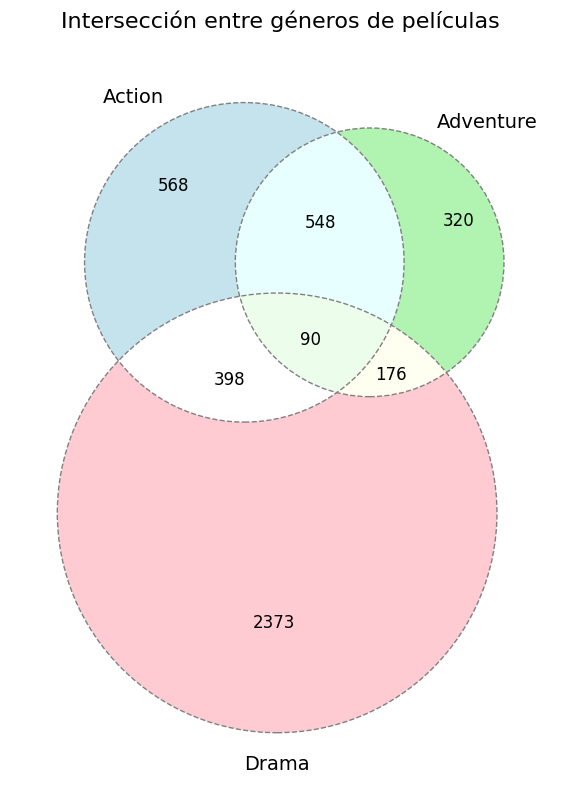

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn3_circles

# Cargamos el dataset
df = pd.read_csv(r"C:\Users\Silvia\Desktop\Master\Asignaturas\Visualización\PEC2\IMDb_All_Genres_etf_clean1.csv")

# Limpiamos las columnas de espacios vacíos
df['main_genre'] = df['main_genre'].str.strip()
df['side_genre'] = df['side_genre'].str.strip()

# Combinamos el campo del género principal y el subgénero en una sola columna
df["genres"] = df["main_genre"].fillna('') + "," + df["side_genre"].fillna('')

# Agrupamos las películas según pertenezcan al género Acción, Aventura o Drama
action = set(df[df['genres'].str.contains("Action", na=False)]['Movie_Title'])
adventure = set(df[df['genres'].str.contains("Adventure", na=False)]['Movie_Title'])
drama = set(df[df['genres'].str.contains("Drama", na=False)]['Movie_Title'])

# Creamos el Venn Diagram
plt.figure(figsize=(8,8))

v = venn3(
    [action, adventure, drama],
    ('Action', 'Adventure', 'Drama'),
    set_colors=('lightblue', 'lightgreen', 'lightpink'),
    alpha=0.7
)

c = venn3_circles([action, adventure, drama], linestyle='dashed', linewidth=1, color="gray")

# Etiquetas con el número de películas
for text in v.set_labels:
    text.set_fontsize(14)
for text in v.subset_labels:
    if text:  
        text.set_fontsize(12)

plt.title("Intersección entre géneros de películas", fontsize=16, pad=20)

plt.tight_layout()
plt.show()

# Marimekko Chart

### Origen

No tiene un único creador claramente identificado, el nombre procede de la marca finlandesa Marimekko
    
### Ventajas
    
- Permite visualizar dos dimensiones de proporción simultáneamente.
- Muy útil para mostrar cuotas de mercado o composición de segmentos.
- Permite analizar relaciones entre dos variables categóricas.
- Permite identificar rápidamente qué segmentos son más grandes o dominantes.

### Inconvenientes

- Puede ser difícil de interpretar para usuarios no familiarizados.
- Las comparaciones entre bloques pueden resultar complicadas si los tamaños son muy diferentes.
- No es adecuado cuando hay muchas categorías, ya que el gráfico se vuelve confuso.
- La estimación visual de áreas no es tan precisa como en otros gráficos.

### Tipos de datos

- Variables categóricas nominales
- Valores cuantitativos agregados (frecuencias, porcentajes o ventas)

En el gráfico:
- Ancho de cada columna → tamaño de la primera categoría (por ejemplo Región).
- Altura de cada bloque dentro de la columna → proporción de la segunda categoría (Producto).

### Aplicaciones

 
- Análisis de cuotas de mercado
- Segmentación de clientes o productos
- Distribución de ventas por región y categoría

**Referencias:**
- https://www.fusioncharts.com/dev/chart-guide/standard-charts/marimekko-chart
- https://www.jaspersoft.com/es/articles/what-is-a-marimekko-chart
- Dataset: https://www.kaggle.com/datasets/dmahajanbe23/bmw-global-automotive-sales

C:\Users\Silvia\AppData\Local\Temp\ipykernel_22524\2767096973.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20')(np.linspace(0, 1, len(models)))
C:\Users\Silvia\AppData\Local\Temp\ipykernel_22524\2767096973.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  current_width = widths[i]
C:\Users\Silvia\AppData\Local\Temp\ipykernel_22524\2767096973.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])


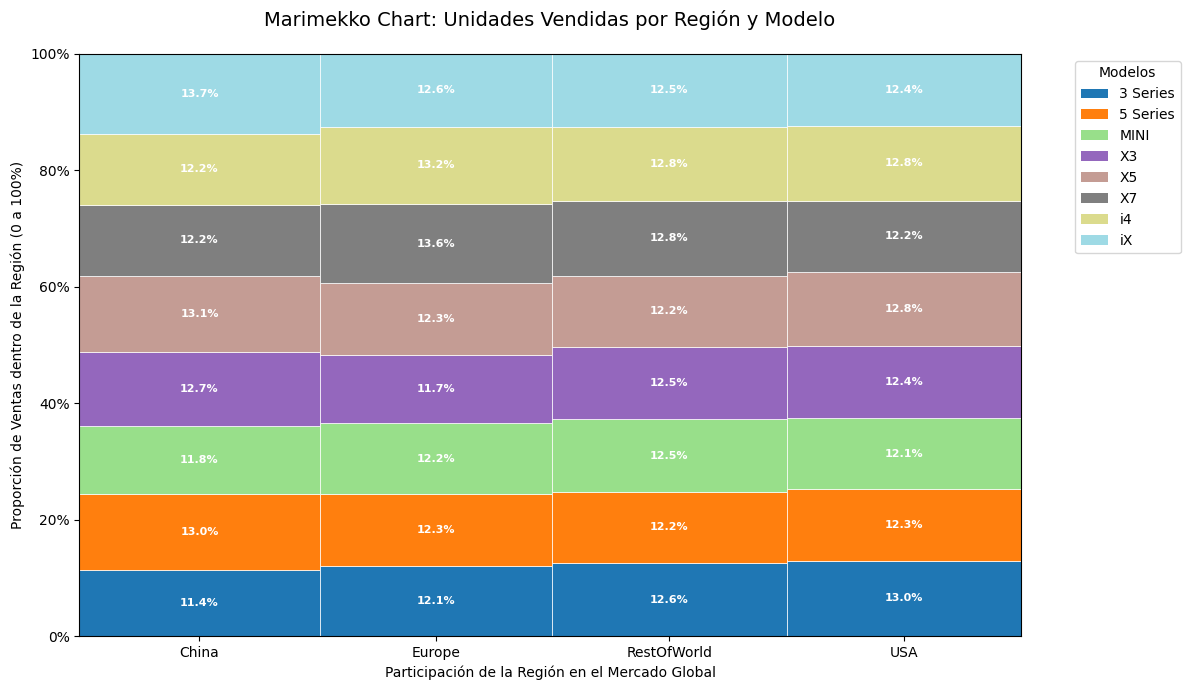

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cargamos el dataset
df_1 = pd.read_csv(r"C:\Users\Silvia\Desktop\Master\Asignaturas\Visualización\PEC2\bmw_global_sales_2018_2025.csv")
#print(df_1.head())

# Agrupar por región y modelo
grouped = df_1.groupby(['Region','Model'], as_index=False)['Units_Sold'].sum()

# Total por región y total global
region_totals = grouped.groupby('Region')['Units_Sold'].sum()
total_global = region_totals.sum()

# Anchos proporcionales 
widths = region_totals / total_global

positions = np.zeros(len(widths))
positions[1:] = np.cumsum(widths[:-1])


fig, ax = plt.subplots(figsize=(12, 7))

models = grouped['Model'].unique()
colors = plt.cm.get_cmap('tab20')(np.linspace(0, 1, len(models)))
model_color_map = dict(zip(models, colors))

# Marimekko Chart
for i, region in enumerate(region_totals.index):
    subset = grouped[grouped['Region'] == region]
    current_left = positions[i]
    current_width = widths[i]
    bottom = 0
    
    total_region = subset['Units_Sold'].sum()
    
    for _, row in subset.iterrows():
        
        height = row['Units_Sold'] / total_region
        
        ax.bar(
            current_left, 
            height, 
            width=current_width, 
            bottom=bottom, 
            color=model_color_map[row['Model']], 
            edgecolor='white',
            align='edge',   
            linewidth=0.5
        )
        
        
        if height > 0.05:
            ax.text(
                current_left + current_width/2, 
                bottom + height/2, 
                f"{height:.1%}", 
                va='center', ha='center', fontsize=8, color='white', weight='bold'
            )
            
        bottom += height

# Etiquetas
ax.set_title('Marimekko Chart: Unidades Vendidas por Región y Modelo', pad=20, fontsize=14)
ax.set_ylabel('Proporción de Ventas dentro de la Región (0 a 100%)')
ax.set_xlabel('Participación de la Región en el Mercado Global')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_xticks(positions + widths/2)
ax.set_xticklabels(region_totals.index)

ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=model_color_map[m], label=m) for m in models]
ax.legend(handles=legend_elements, title='Modelos', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Violin Plot

### Origen

- Una evolución del boxplot para representar la distribución completa de los datos.
- Se popularizó en la década de 1990 con el auge de herramientas estadísticas como R y su capacidad de generar estimaciones de densidad suavizadas. 
    
### Ventajas
    
- Muestra la distribución completa de la variable en lugar de solo medianas y cuartiles.
- Permite comparar distribuciones entre varios grupos.
- Muestra simetría, sesgo y multimodalidad de forma clara.
- Puede combinarse con boxplots para resaltar medianas y cuartiles dentro del violín.
- Muy útil cuando se tienen muchos datos y no es práctico graficarlos individualmente.

### Inconvenientes

- Para muy pocos datos, la estimación de densidad puede ser engañosa.
- La densidad visual puede confundir si los tamaños de grupo son muy diferentes.
- No es tan intuitivo para personas que no están familiarizadas con la densidad de probabilidad.
- Comparar violines de tamaños muy distintos puede inducir a interpretaciones incorrectas.

### Tipos de datos

- Variable numérica continua (la que se representa en el eje Y o X según orientación).
- Variable categórica opcional para separar violines por grupos (ej. género, región, tratamiento).

### Aplicaciones
 
- Distribución de peso o altura de diferentes especies de animales.
- Comparación de salarios entre departamentos de una empresa.
- Distribución de puntuaciones en exámenes según grupo o categoría.
- Comparación de rendimiento de algoritmos o modelos de Machine Learning por dataset.

**Referencias:**
- https://www.data-to-viz.com/graph/violin.html?utm_source=chatgpt.com
- Dataset: https://www.kaggle.com/datasets/spscientist/students-performance-in-exam

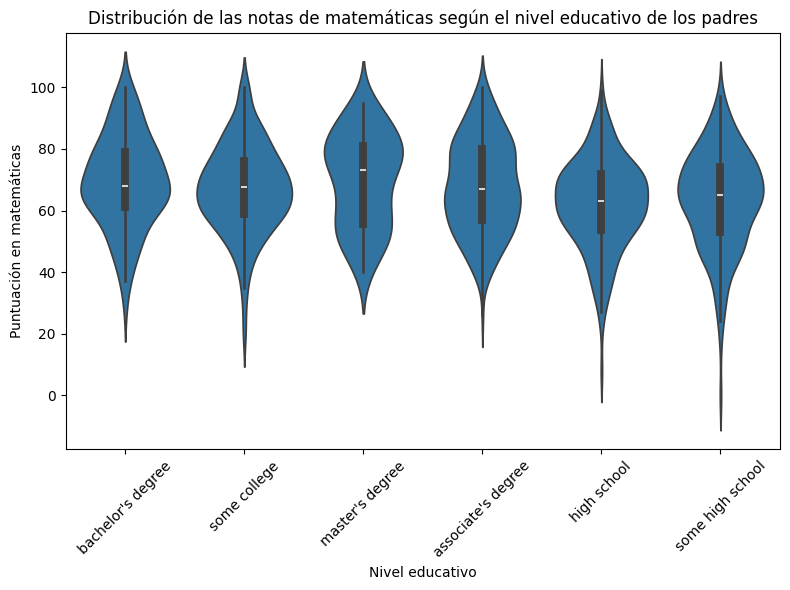

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargamos el Dataset
df = pd.read_csv(r"C:\Users\Silvia\Desktop\Master\Asignaturas\Visualización\PEC2\StudentsPerformance.csv")


df.columns = df.columns.str.strip()

plt.figure(figsize=(8,6))

sns.violinplot(x="parental level of education", y="math score", data=df)

plt.xticks(rotation=45)

plt.title("Distribución de las notas de matemáticas según el nivel educativo de los padres")
plt.xlabel("Nivel educativo")
plt.ylabel("Puntuación en matemáticas")

plt.tight_layout()
plt.show()


El **violin plot** muestra la distribución de las puntuaciones de matemáticas (`math score`) según el nivel educativo de los padres (`parental level of education`). La forma de cada violín representa la densidad de los datos: las zonas más anchas indican valores donde se concentran más estudiantes, mientras que las zonas más estrechas indican menos observaciones.

En el interior de cada violín aparece un **boxplot**, que permite identificar la mediana y el rango intercuartílico de las puntuaciones. En la mayoría de los grupos, la mediana se sitúa aproximadamente entre **65 y 70 puntos**, y la mayor parte de los valores se concentra entre **60 y 75 puntos**.

Las distribuciones entre las distintas categorías son bastante similares y presentan una gran superposición. Esto sugiere que, en este dataset, el nivel educativo de los padres no genera diferencias muy marcadas en las puntuaciones de matemáticas de los estudiantes, aunque los grupos con **bachelor's degree** o **master's degree** muestran ligeramente valores más altos.
